source data : https://www.kaggle.com/code/hamzaboulahia

1. Import Library yang Dibutuhkan

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Import Dataset Dari Google Drive

In [22]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Klasifikasi Tumor Otak/metadata.csv")

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Unnamed: 0            image  class format mode          shape
0           0   Cancer (1).jpg  tumor   JPEG  RGB  (512, 512, 3)
1           1   Cancer (1).png  tumor    PNG    L     (300, 240)
2           2   Cancer (1).tif  tumor   TIFF  RGB  (256, 256, 3)
3           3  Cancer (10).jpg  tumor   JPEG  RGB  (512, 512, 3)
4           4  Cancer (10).tif  tumor   TIFF  RGB  (256, 256, 3)


3. Data Cleaning

In [23]:
print(df.isnull().sum())

Unnamed: 0    0
image         0
class         0
format        0
mode          0
shape         0
dtype: int64


4. Informasi Dataset

In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4600 non-null   int64 
 1   image       4600 non-null   object
 2   class       4600 non-null   object
 3   format      4600 non-null   object
 4   mode        4600 non-null   object
 5   shape       4600 non-null   object
dtypes: int64(1), object(5)
memory usage: 215.8+ KB
None


5. Statistik Dataset

In [25]:
print(df.describe())

        Unnamed: 0
count  4600.000000
mean   2299.500000
std    1328.049949
min       0.000000
25%    1149.750000
50%    2299.500000
75%    3449.250000
max    4599.000000


6. Encoding Label Class

In [26]:
le = LabelEncoder()

df['class'] = le.fit_transform(df['class'])

print(df['class'].value_counts())

class
1    2513
0    2087
Name: count, dtype: int64


7. Encoding Fitur Kategorikal

In [28]:
df['format'] = LabelEncoder().fit_transform(df['format'])
df['mode'] = LabelEncoder().fit_transform(df['mode'])
df['shape'] = LabelEncoder().fit_transform(df['shape'])

8. Menghapus Kolom Yang Tidak Digunakan

In [29]:
df = df.drop(['Unnamed: 0','image'], axis=1)

print(df.head())

   class  format  mode  shape
0      1       0     2    395
1      1       1     0    212
2      1       2     2    154
3      1       0     2    395
4      1       2     2    154


9. Visualisasi Distribusi Class

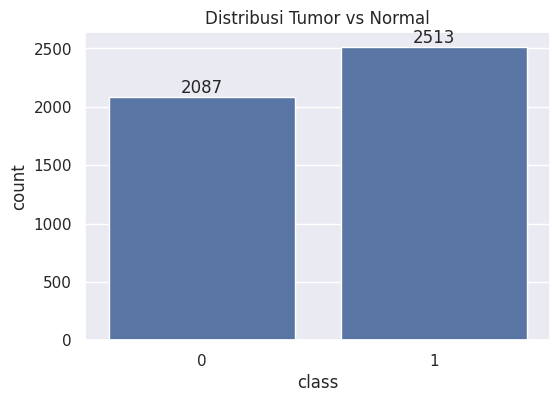

In [30]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='class', data=df)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribusi Tumor vs Normal")
plt.show()

10. Menentukan Feature dan Target

In [31]:
X = df.drop('class', axis=1)
y = df['class']

11. Split Data Training dan Testing

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

12. Normalisasi Data

In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

13. Training Model SVM

In [34]:
svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

SVC()

14. Prediksi Model

In [35]:
y_pred = svm_model.predict(X_test)

15. Akurasi Model

In [36]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy SVM :", accuracy)

Accuracy SVM : 0.7597826086956522


16. Confusion Matrix

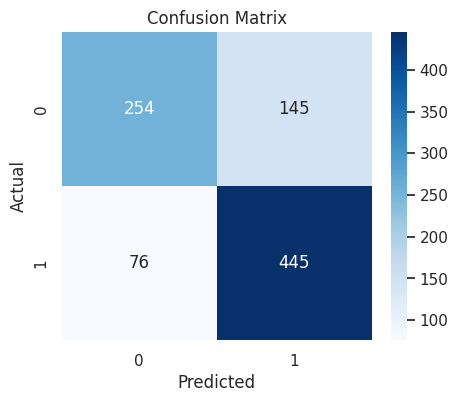

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

17. Classification Report

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.64      0.70       399
           1       0.75      0.85      0.80       521

    accuracy                           0.76       920
   macro avg       0.76      0.75      0.75       920
weighted avg       0.76      0.76      0.76       920

